In [36]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

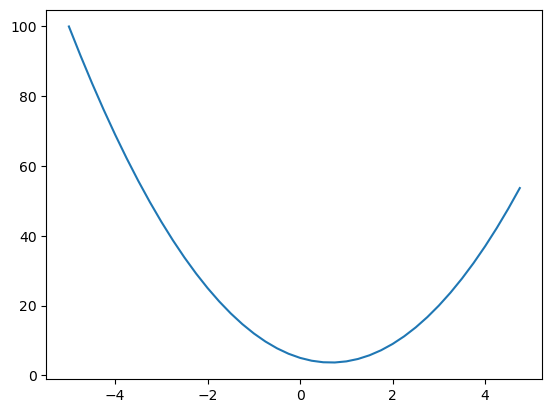

In [6]:
plt.plot(xs, ys)

In [7]:
h = 0.00000001
x = 3
derivative = (f(x + h) - f(x))/h
derivative

14.00000009255109

In [8]:
h = 0.00000001
x = -3
derivative = (f(x + h) - f(x))/h
derivative

-22.00000039920269

In [9]:
h = 0.0000001
x = 2/3
derivative = (f(x + h) - f(x))/h
derivative

2.9753977059954195e-07

In [10]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
d

4.0

In [11]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [12]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label = ''):
        # _children defined as tuple initially for efficieny but finally stored and used as a set
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        
        return out
    
    def __radd__(self, other): # other + self
        return self + other

    def __neg__(self): # -self
        return self * -1

    # Use addition and negation to subtract
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        
        return out
    
    # If we try to do 2 * a it fails because it calls 2.__mul__(a) and 2 can't multiply a Value
    # As a fallback we add __rmul__ because python will check if we can't do 2 * a, is there any 
    # way a knows how to multiply with 2.
    def __rmul__(self, other): # other * self
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
            
        out._backward = _backward

        return out
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        
        return out
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad # Derivative of e^x is e^x and we just stored e^x in out
            
        out._backward = _backward
        
        return out
    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        

In [13]:
a = Value(2.0)
a

Value(data = 2.0)

In [14]:
a = Value(2.0)
b = Value(-3.0)

a + b
# when we do a + b, internally python calls a.__add__(b)

Value(data = -1.0)

In [15]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')

e = a*b
# a.__mul__(b)
e.label = 'e'
d = e + c
# e.__add__(c)
d.label = 'd'

f = Value(-2.0, label = 'f')
L = d * f
L.label = 'L'

In [16]:
d._prev

{Value(data = -6.0), Value(data = 10.0)}

In [17]:
d._op

'+'

In [18]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

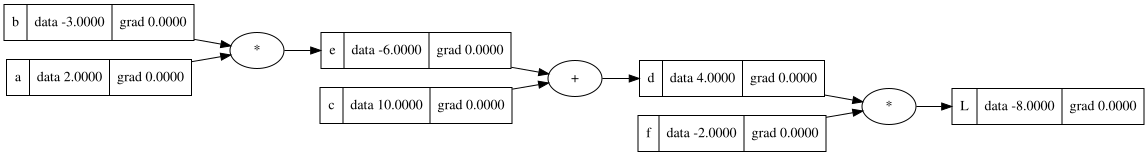

In [19]:
draw_dot(L)

In [20]:
# Using Chain Rule

L.grad = 1.0
d.grad = -2.0 * L.grad
f.grad = 4.0 * L.grad

# As we can observe addition is just a distributor of gradient and flows the same gradient back to its children
e.grad = d.grad * 1
c.grad = d.grad * 1

b.grad = e.grad * a.data
a.grad = e.grad * b.data

In [21]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [22]:
# Trying manual backpropagation on a NN

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b

x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2*w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

o = n.tanh()
o.label = 'o'

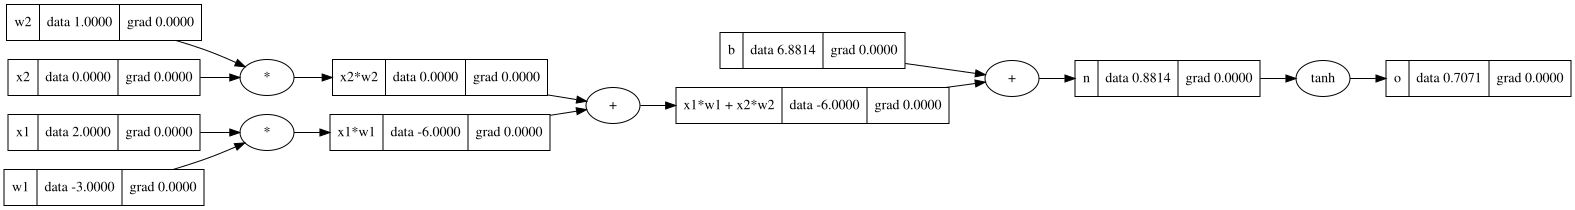

In [23]:
draw_dot(o)

In [24]:
# Manually
o.grad = 1.0

# derivative of tanh(x) is 1 - tanh(x)**2
n.grad = 1 - o.data**2

# Addition just flows the gradient
x1w1x2w2.grad = n.grad
b.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data
x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

In [25]:
# Using _backward()
o.grad = 1.0

o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [26]:
# Now instead of calling _backward() manually we will automate it as well using topological sort.
# Topological sorting is a linear ordering of vertices in a Directed Acyclic Graph (DAG) such that for every directed edge 
# u -> v, vertex u comes before vertex v.
# This help in ensuring that the latter gradient is ready before we call _backward for its children.

o.backward()

In [27]:
# Manually implementing tanh using exponents

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b

x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2*w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

e = (2*n).exp()
o = (e - 1)/(e + 1)
o.label = 'o'

In [28]:
o.backward()

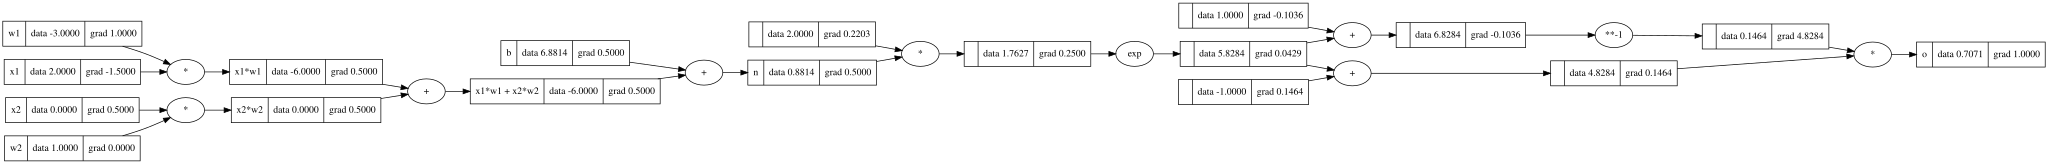

In [29]:
draw_dot(o)

In [30]:
import torch

In [ ]:
# Have to set .requires_grad = True manually because by default it is set to False for efficiency 
# because usually we don't need gradients for leaf nodes

# Have to set .double() because Python by default uses double precision for floating point numbers and torch has float32
# casting it to .double() helps with consistency

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True 
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [74]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  # When we do n(x), where n is a Neuron object and x is a tensor,
  # Python internally calls the __call__ method of the object.
  def __call__(self, x):    # w * x + b
    # sum takes an optional second argument to basically which is added to the final result.
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    # returns a list
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    # Creates nout neurons, each taking nin inputs
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    # Pass input x through all neurons and collect their outputs
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    # returns a list
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    # here nouts is a list
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    # Pass x sequentially through all layers and return the final output
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    # returns a list
    return [p for layer in self.layers for p in layer.parameters()]

In [75]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data = 0.3461455651294937)

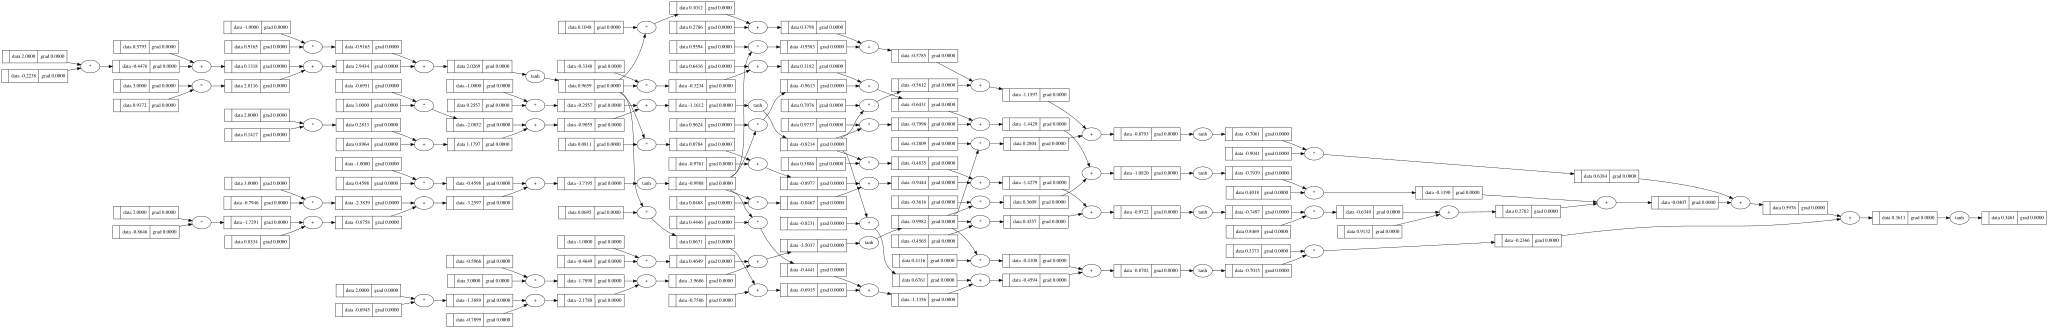

In [76]:
draw_dot(n(x))

In [77]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [78]:
# We can try getting predictions using the neural network
ypred = [n(x) for x in xs]
ypred

[Value(data = 0.3461455651294937),
 Value(data = 0.41572718584726476),
 Value(data = 0.09441953705807761),
 Value(data = 0.39103069675059804)]

In [79]:
# Let's calculate Mean Squared Error (MSE) loss
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data = 4.000406822141324)

In [80]:
loss.backward()

In [81]:
# We know have gradients for all our neurons
# For example:
n.layers[0].neurons[0].w[0]

Value(data = -0.22378215166766902)

In [71]:
# draw_dot(loss)

In [82]:
# Let's calculate Mean Squared Error (MSE) loss
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data = 4.000406822141324)

In [108]:
# Updated loss after updating parameters
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data = 2.2485359674320495e-25)

In [109]:
loss.backward()

In [110]:
for p in n.parameters():
# 0.1 is the learning rate of this gradient descent
    p.data += -0.1 * p.grad # Negative sign because we want to minimise the loss, the gradient points in positive direction


In [111]:
# Training loop doing 20 iterations
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    # 0.1 is the learning rate of this gradient descent
    p.data += -0.1 * p.grad # Negative sign because we want to minimise the loss, the gradient points in positive direction
    # Easier to understand if you think gradient is positive so increasing would increase loss and if we didn't had the negative sign
    # here then value would have increased and hence the loss.
  
  print(k, loss.data)

0 7.2549455677467e-14
1 7.2549455677467e-14
2 7.2549455677467e-14
3 7.2549455677467e-14
4 7.2549455677467e-14
5 7.2549455677467e-14
6 7.2549455677467e-14
7 7.2549455677467e-14
8 7.254945561765926e-14
9 7.254945561765926e-14
10 7.254945561765926e-14
11 7.254945561765926e-14
12 7.254945561765926e-14
13 7.254945561765926e-14
14 7.254945561765926e-14
15 7.254945561765926e-14
16 7.254945561765926e-14
17 7.254945561765926e-14
18 7.254945561765926e-14
19 7.254945561765926e-14
